# 3º Entregável — Modelagem de Machine Learning

**Disciplina:** Machine Learning & Modelling  
**Curso:** Tecnologia em Inteligência Artificial  
**Aluno(a):** ______________________________________

## Objetivo

Construir e avaliar modelos de **classificação de risco em dispositivos IoT**, contemplando os requisitos do entregável:

- preparação dos dados com **scaling** e **encoding**;
- treinamento de pelo menos **2 modelos**;
- validação por **holdout**;
- métricas **accuracy, precision, recall, F1-score e AUC**;
- **tuning de hiperparâmetros**;
- interpretação das variáveis que mais impactam o risco.

Neste projeto, a variável alvo `risco_alto` assume:

- `0` = situação normal / sem alto risco;
- `1` = situação de alto risco.

> O dataset é sintético e reproduzível, criado para fins acadêmicos. O alvo contém componente probabilístico e ruído, de modo que o problema não seja artificialmente perfeito.

## 1. Importação das bibliotecas

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
PASTA_RAIZ = Path.cwd()
PASTA_DADOS = PASTA_RAIZ / "data"
PASTA_RESULTADOS = PASTA_RAIZ / "resultados"
PASTA_RESULTADOS.mkdir(exist_ok=True)

pd.set_option("display.max_columns", None)
print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


## 2. Carregamento e inspeção dos dados

O conjunto contém medições operacionais e de segurança de dispositivos IoT. Antes da modelagem, verificamos dimensões, tipos, valores ausentes e distribuição da classe alvo.

In [2]:
caminho_csv = PASTA_DADOS / "dados_iot_ml.csv"
df = pd.read_csv(caminho_csv)

print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")
display(df.head())

Quantidade de linhas: 1400
Quantidade de colunas: 13


,temperatura_c,umidade_pct,perda_pacotes_pct,latencia_ms,tentativas_login_falhas,idade_firmware_dias,consumo_cpu_pct,trafego_saida_kbps,criptografia_ativa,protocolo,rede,tipo_equipamento,risco_alto
0,30.13,73.29,2.82,110.83,1,61,58.98,99.77,sim,CoAP,iot_isolada,sensor,0
1,20.72,46.17,1.16,34.89,1,38,21.33,268.56,sim,CoAP,iot_isolada,sensor,0
2,33.25,48.33,6.80,101.95,0,397,48.10,460.81,sim,MQTT,corporativa,sensor,0
3,34.58,43.15,4.02,121.12,0,146,44.10,384.14,sim,CoAP,iot_isolada,sensor,0
4,14.34,41.55,2.22,127.51,0,139,80.95,122.18,sim,MQTT,visitantes,atuador,0


In [3]:
resumo_qualidade = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "valores_ausentes": df.isna().sum(),
    "valores_unicos": df.nunique(),
})
display(resumo_qualidade)

print("Distribuição da variável alvo:")
display(df["risco_alto"].value_counts().rename(index={0: "Normal (0)", 1: "Alto risco (1)"}).to_frame("quantidade"))
print(f"Percentual de alto risco: {df['risco_alto'].mean():.2%}")

,tipo,valores_ausentes,valores_unicos
temperatura_c,float64,0,1087
umidade_pct,float64,0,1243
perda_pacotes_pct,float64,0,827
latencia_ms,float64,0,1343
tentativas_login_falhas,int64,0,8
idade_firmware_dias,int64,0,525
consumo_cpu_pct,float64,0,1283
trafego_saida_kbps,float64,0,1381
criptografia_ativa,object,0,2
protocolo,object,0,3


Distribuição da variável alvo:


,quantidade
risco_alto,
Normal (0),815
Alto risco (1),585


Percentual de alto risco: 41.79%


## 3. Separação entre variáveis de entrada e alvo

A coluna `risco_alto` é retirada das variáveis de entrada. Também não incluímos um score de risco pronto entre as features, pois isso provocaria **data leakage**: o modelo receberia uma informação que já resume a resposta que deve aprender a prever.

In [4]:
X = df.drop(columns=["risco_alto"])
y = df["risco_alto"]

variaveis_numericas = X.select_dtypes(include="number").columns.tolist()
variaveis_categoricas = X.select_dtypes(exclude="number").columns.tolist()

print("Variáveis numéricas:")
print(variaveis_numericas)
print("\nVariáveis categóricas:")
print(variaveis_categoricas)

Variáveis numéricas:
['temperatura_c', 'umidade_pct', 'perda_pacotes_pct', 'latencia_ms', 'tentativas_login_falhas', 'idade_firmware_dias', 'consumo_cpu_pct', 'trafego_saida_kbps']

Variáveis categóricas:
['criptografia_ativa', 'protocolo', 'rede', 'tipo_equipamento']


## 4. Preparação dos dados: scaling e encoding

São aplicadas duas transformações:

1. **StandardScaler** nas colunas numéricas, colocando-as em escala comparável. Essa etapa é especialmente importante para modelos lineares e métodos baseados em distância.
2. **OneHotEncoder (OHE)** nas variáveis categóricas, convertendo categorias em colunas binárias sem criar uma ordem artificial entre elas.

O `ColumnTransformer` garante que cada transformação seja aplicada somente ao grupo correto de colunas. O pré-processamento é colocado dentro do `Pipeline`, evitando vazamento entre treino e teste.

In [5]:
preprocessador = ColumnTransformer([
    ("numericas", StandardScaler(), variaveis_numericas),
    ("categoricas", OneHotEncoder(handle_unknown="ignore"), variaveis_categoricas),
])

print("Pré-processador configurado:")
print(preprocessador)

Pré-processador configurado:
ColumnTransformer(transformers=[('numericas', StandardScaler(),
                                 ['temperatura_c', 'umidade_pct',
                                  'perda_pacotes_pct', 'latencia_ms',
                                  'tentativas_login_falhas',
                                  'idade_firmware_dias', 'consumo_cpu_pct',
                                  'trafego_saida_kbps']),
                                ('categoricas',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['criptografia_ativa', 'protocolo', 'rede',
                                  'tipo_equipamento'])])


## 5. Holdout obrigatório

O dataset é dividido em **80% para treinamento** e **20% para teste final**. A opção `stratify=y` mantém aproximadamente a mesma proporção de classes nos dois conjuntos.

O conjunto de teste ficará isolado durante o treinamento e durante o tuning de hiperparâmetros.

In [6]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Treino: {len(X_treino)} registros ({len(X_treino)/len(X):.0%})")
print(f"Teste:  {len(X_teste)} registros ({len(X_teste)/len(X):.0%})")
print(f"Alto risco no treino: {y_treino.mean():.2%}")
print(f"Alto risco no teste:  {y_teste.mean():.2%}")

Treino: 1120 registros (80%)
Teste:  280 registros (20%)
Alto risco no treino: 41.79%
Alto risco no teste:  41.79%


## 6. Modelo 1 — Regressão Logística

A Regressão Logística será usada como primeiro modelo. Ela é uma boa baseline para classificação binária e permite verificar se relações aproximadamente lineares já conseguem separar situações de alto risco.

In [7]:
modelo_logistico = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

modelo_logistico.fit(X_treino, y_treino)
print("Regressão Logística treinada.")

Regressão Logística treinada.


## 7. Modelo 2 — Random Forest + tuning básico

O segundo modelo é uma Random Forest. Em vez de aceitar apenas os valores padrão, realizamos um **tuning básico** com `GridSearchCV`.

São testados:

- `n_estimators`: quantidade de árvores;
- `max_depth`: profundidade máxima;
- `min_samples_leaf`: mínimo de amostras permitido em uma folha.

A busca usa validação cruzada de 5 folds **somente no conjunto de treinamento** e otimiza o **F1-score**. Assim, o holdout continua preservado para a avaliação final.

In [8]:
pipeline_rf = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
    )),
])

parametros = {
    "modelo__n_estimators": [150, 300],
    "modelo__max_depth": [4, 7, None],
    "modelo__min_samples_leaf": [1, 3, 6],
}

busca_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=parametros,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    return_train_score=False,
)

busca_rf.fit(X_treino, y_treino)
modelo_rf = busca_rf.best_estimator_

print("Melhores hiperparâmetros:")
print(busca_rf.best_params_)
print(f"Melhor F1 médio na validação cruzada: {busca_rf.best_score_:.4f}")

with open(PASTA_RESULTADOS / "melhores_hiperparametros.json", "w", encoding="utf-8") as arquivo:
    json.dump(busca_rf.best_params_, arquivo, indent=2, ensure_ascii=False)

Melhores hiperparâmetros:
{'modelo__max_depth': None, 'modelo__min_samples_leaf': 6, 'modelo__n_estimators': 300}
Melhor F1 médio na validação cruzada: 0.5931


### Visualização do tuning

O gráfico abaixo resume o F1 médio obtido pelas combinações de hiperparâmetros testadas.

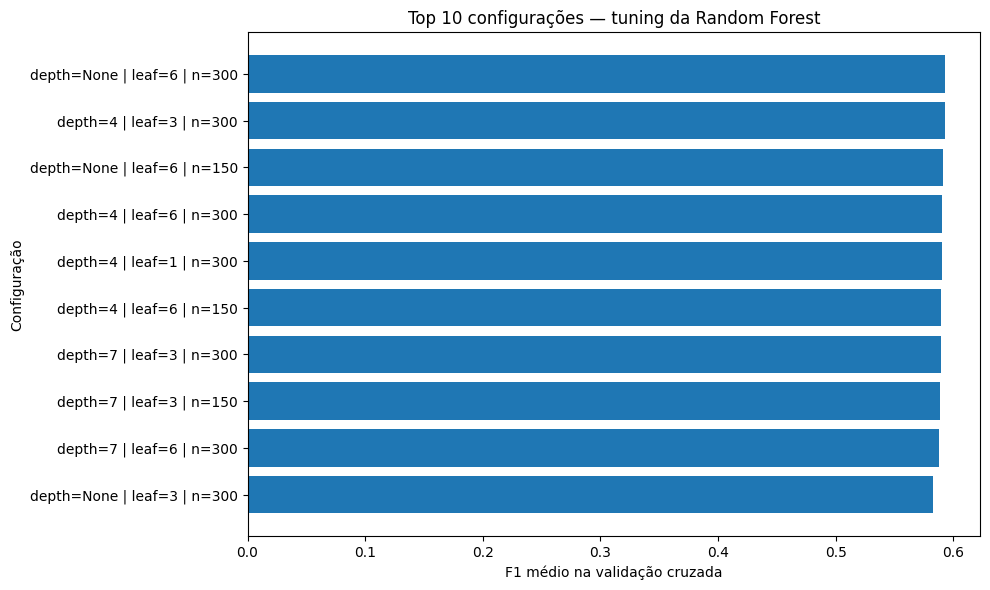

In [9]:
resultados_cv = pd.DataFrame(busca_rf.cv_results_).sort_values("mean_test_score", ascending=False).reset_index(drop=True)
resultados_cv["configuracao"] = resultados_cv.apply(
    lambda r: f"depth={r['param_modelo__max_depth']} | leaf={r['param_modelo__min_samples_leaf']} | n={r['param_modelo__n_estimators']}",
    axis=1,
)

top_tuning = resultados_cv.head(10).sort_values("mean_test_score")
plt.figure(figsize=(10, 6))
plt.barh(top_tuning["configuracao"], top_tuning["mean_test_score"])
plt.xlabel("F1 médio na validação cruzada")
plt.ylabel("Configuração")
plt.title("Top 10 configurações — tuning da Random Forest")
plt.tight_layout()
plt.savefig(PASTA_RESULTADOS / "tuning_random_forest.png", dpi=160, bbox_inches="tight")
plt.show()

## 8. Avaliação final no holdout

Agora os dois modelos são avaliados **uma única vez** no conjunto de teste reservado. As métricas são:

- **Accuracy:** percentual total de previsões corretas;
- **Precision:** entre os casos previstos como alto risco, quantos realmente eram alto risco;
- **Recall:** entre os casos realmente de alto risco, quantos foram identificados;
- **F1-score:** equilíbrio entre precision e recall;
- **AUC:** capacidade do modelo de ordenar positivos acima de negativos ao variar o limiar de classificação.

In [10]:
def avaliar_modelo(nome, modelo, X_avaliacao, y_real):
    previsao = modelo.predict(X_avaliacao)
    probabilidade = modelo.predict_proba(X_avaliacao)[:, 1]
    return {
        "modelo": nome,
        "accuracy": accuracy_score(y_real, previsao),
        "precision": precision_score(y_real, previsao, zero_division=0),
        "recall": recall_score(y_real, previsao, zero_division=0),
        "f1_score": f1_score(y_real, previsao, zero_division=0),
        "auc": roc_auc_score(y_real, probabilidade),
    }

metricas = pd.DataFrame([
    avaliar_modelo("Regressão Logística", modelo_logistico, X_teste, y_teste),
    avaliar_modelo("Random Forest Tunada", modelo_rf, X_teste, y_teste),
])

metricas.to_csv(PASTA_RESULTADOS / "metricas_modelos.csv", index=False)
display(metricas.round(4))

,modelo,accuracy,precision,recall,f1_score,auc
0,Regressão Logística,0.7107,0.6875,0.5641,0.6197,0.7558
1,Random Forest Tunada,0.6929,0.6348,0.6239,0.6293,0.7319


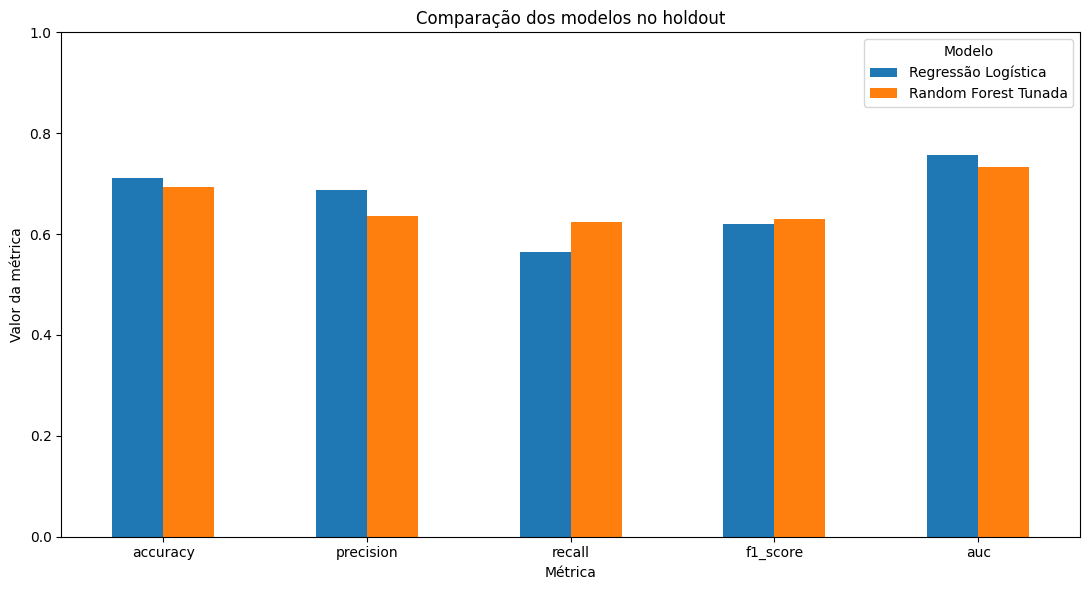

In [11]:
metricas_plot = metricas.set_index("modelo")[["accuracy", "precision", "recall", "f1_score", "auc"]].T
ax = metricas_plot.plot(kind="bar", figsize=(11, 6))
ax.set_ylim(0, 1)
ax.set_ylabel("Valor da métrica")
ax.set_xlabel("Métrica")
ax.set_title("Comparação dos modelos no holdout")
plt.xticks(rotation=0)
plt.legend(title="Modelo")
plt.tight_layout()
plt.savefig(PASTA_RESULTADOS / "comparacao_metricas.png", dpi=160, bbox_inches="tight")
plt.show()

## 9. Matrizes de confusão

A matriz de confusão permite observar verdadeiros positivos, verdadeiros negativos, falsos positivos e falsos negativos.

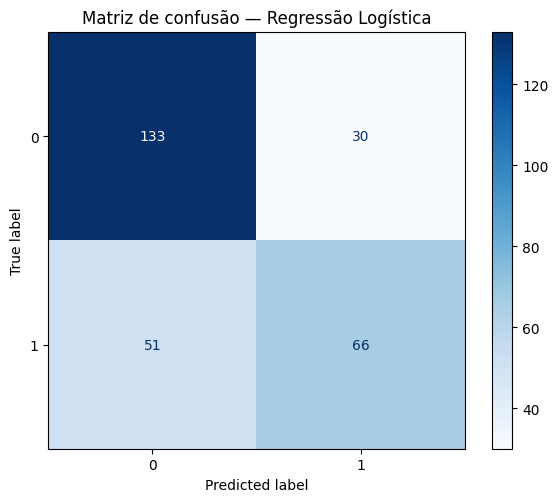

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(modelo_logistico, X_teste, y_teste, cmap="Blues", ax=ax)
ax.set_title("Matriz de confusão — Regressão Logística")
plt.tight_layout()
plt.savefig(PASTA_RESULTADOS / "matriz_confusao_logistica.png", dpi=160, bbox_inches="tight")
plt.show()

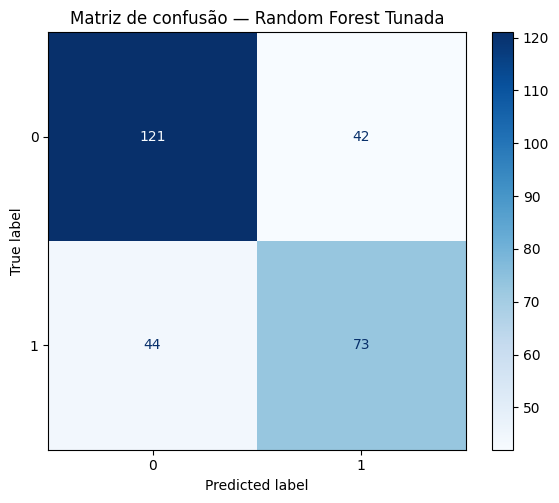

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(modelo_rf, X_teste, y_teste, cmap="Blues", ax=ax)
ax.set_title("Matriz de confusão — Random Forest Tunada")
plt.tight_layout()
plt.savefig(PASTA_RESULTADOS / "matriz_confusao_random_forest.png", dpi=160, bbox_inches="tight")
plt.show()

## 10. Curva ROC e AUC

A curva ROC compara a taxa de verdadeiros positivos com a taxa de falsos positivos para diferentes limiares. Quanto maior a AUC, melhor a capacidade geral de discriminação.

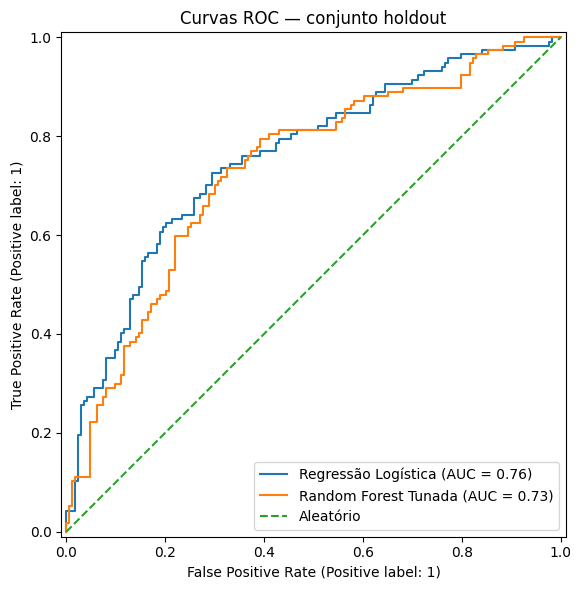

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_estimator(modelo_logistico, X_teste, y_teste, name="Regressão Logística", ax=ax)
RocCurveDisplay.from_estimator(modelo_rf, X_teste, y_teste, name="Random Forest Tunada", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", label="Aleatório")
ax.set_title("Curvas ROC — conjunto holdout")
ax.legend()
plt.tight_layout()
plt.savefig(PASTA_RESULTADOS / "curvas_roc.png", dpi=160, bbox_inches="tight")
plt.show()

## 11. Interpretação — quais variáveis mais impactam o risco?

Para responder à questão de interpretação, usamos **Permutation Importance** na Random Forest tunada. O método embaralha uma variável por vez e mede quanto a AUC piora. Quanto maior a queda, maior a dependência do modelo em relação àquela variável.

A vantagem aqui é obter importância diretamente no nível das variáveis originais, incluindo as categóricas antes do OHE.

In [15]:
perm = permutation_importance(
    modelo_rf,
    X_teste,
    y_teste,
    n_repeats=15,
    random_state=RANDOM_STATE,
    scoring="roc_auc",
)

importancia = pd.DataFrame({
    "variavel": X_teste.columns,
    "importancia_media_auc": perm.importances_mean,
    "desvio_padrao": perm.importances_std,
}).sort_values("importancia_media_auc", ascending=False).reset_index(drop=True)

importancia.to_csv(PASTA_RESULTADOS / "importancia_variaveis.csv", index=False)
display(importancia.round(4))

,variavel,importancia_media_auc,desvio_padrao
0,perda_pacotes_pct,0.0430,0.0148
1,tentativas_login_falhas,0.0400,0.0089
2,temperatura_c,0.0379,0.0116
3,criptografia_ativa,0.0372,0.0082
4,umidade_pct,0.0315,0.0081
5,latencia_ms,0.0281,0.0113
6,idade_firmware_dias,0.0070,0.0224
7,trafego_saida_kbps,0.0051,0.0027
8,tipo_equipamento,0.0006,0.0032
9,rede,-0.0008,0.0039


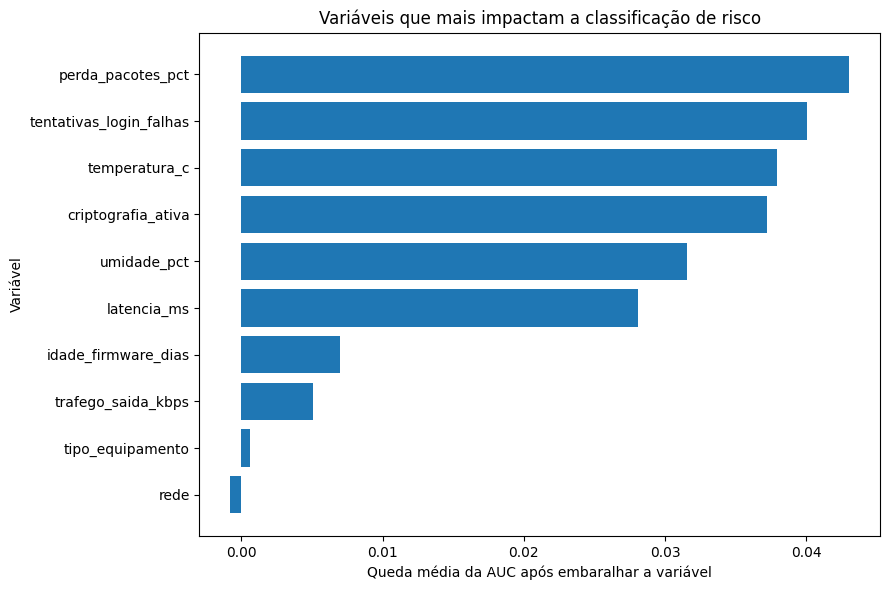

Top 5 variáveis mais relevantes para o modelo:
1. perda_pacotes_pct — importância média 0.0430
2. tentativas_login_falhas — importância média 0.0400
3. temperatura_c — importância média 0.0379
4. criptografia_ativa — importância média 0.0372
5. umidade_pct — importância média 0.0315


In [16]:
top_importancia = importancia.head(10).sort_values("importancia_media_auc")
plt.figure(figsize=(9, 6))
plt.barh(top_importancia["variavel"], top_importancia["importancia_media_auc"])
plt.xlabel("Queda média da AUC após embaralhar a variável")
plt.ylabel("Variável")
plt.title("Variáveis que mais impactam a classificação de risco")
plt.tight_layout()
plt.savefig(PASTA_RESULTADOS / "importancia_variaveis.png", dpi=160, bbox_inches="tight")
plt.show()

print("Top 5 variáveis mais relevantes para o modelo:")
for posicao, linha in importancia.head(5).iterrows():
    print(f"{posicao + 1}. {linha['variavel']} — importância média {linha['importancia_media_auc']:.4f}")

### Como interpretar o resultado

As primeiras posições do ranking são as variáveis cuja alteração destrói mais informação útil para o modelo. Neste cenário IoT, fatores como falhas de autenticação, perda de pacotes, firmware antigo, ausência de criptografia, latência e condições operacionais anormais podem aumentar a probabilidade de alto risco.

É importante diferenciar **importância preditiva** de causalidade: uma variável importante ajuda o modelo a prever, mas esse resultado sozinho não prova que ela seja a causa de um incidente.

In [17]:
melhor_linha = metricas.sort_values("auc", ascending=False).iloc[0]
top5 = ", ".join(importancia.head(5)["variavel"].tolist())

print("=== CONCLUSÃO AUTOMÁTICA ===")
print(f"Modelo com maior AUC no holdout: {melhor_linha['modelo']} ({melhor_linha['auc']:.4f}).")
print(f"F1-score desse modelo: {melhor_linha['f1_score']:.4f}.")
print(f"Cinco variáveis de maior impacto preditivo: {top5}.")

=== CONCLUSÃO AUTOMÁTICA ===
Modelo com maior AUC no holdout: Regressão Logística (0.7558).
F1-score desse modelo: 0.6197.
Cinco variáveis de maior impacto preditivo: perda_pacotes_pct, tentativas_login_falhas, temperatura_c, criptografia_ativa, umidade_pct.


## 12. Conclusão

O objetivo do entregável foi atendido. O projeto:

- preparou dados numéricos e categóricos com **scaling** e **OHE**;
- treinou **dois modelos de classificação**;
- preservou um **holdout estratificado de 20%** para avaliação final;
- calculou **accuracy, precision, recall, F1-score e AUC**;
- realizou **tuning de hiperparâmetros** na Random Forest com validação cruzada;
- comparou os modelos com tabelas e gráficos;
- interpretou as variáveis mais importantes com **Permutation Importance**.

O desempenho não deve ser interpretado somente pela accuracy. Em um contexto de risco, **recall** e **F1-score** são especialmente relevantes porque falsos negativos podem representar situações perigosas que não foram detectadas.

### Próximos passos possíveis

Em um ambiente real, seria recomendável testar novos algoritmos, tratar desbalanceamento quando necessário, coletar mais observações reais e monitorar mudança de comportamento dos dados ao longo do tempo.

## 13. Publicação no GitHub

Após validar o notebook, publique toda a pasta do projeto em um repositório GitHub. Exemplo:

```bash
git init
git add .
git commit -m "3o entregavel - modelagem de machine learning"
git branch -M main
git remote add origin https://github.com/SEU_USUARIO/machine-learning-modelling-entregavel3.git
git push -u origin main
```

O link do repositório será o segundo item solicitado no entregável, junto com este notebook.